In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from simulation.gen_pend import *

param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=1),
    'b': stats.uniform(loc=0, scale=0.01)
}

times, trajs = gen_trajs(10_000, 3., 128, param_dists)
trajs.shape

(10000, 2, 128)

In [4]:
def to_sincos(trajs):
    sincos = np.concatenate((np.sin(trajs[:, :1]),
                             np.cos(trajs[:, :1])),
                             axis=1)
    return np.concatenate((sincos, trajs[:, 1:]), axis=1)

trajs = to_sincos(trajs)

In [5]:
trajs.shape

(10000, 3, 128)

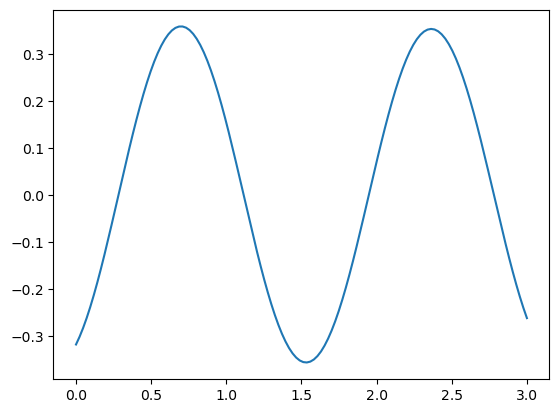

In [6]:
plt.plot(times, trajs[0, 0])

In [7]:
from scipy.fft import dct

def chebyshev_nodes(a, b, n):
    k = np.arange(n + 1)[::-1]
    x = np.cos(np.pi * k / n)          # nodes in [-1, 1]
    # map to [a, b]
    y = 0.5 * (b - a) * x + 0.5 * (a + b)
    return y

def closest2nodes(times, nodes):
    indices = np.searchsorted(times, nodes)
    indices = np.clip(indices, 1, len(times) - 1)

    left_idx = indices - 1
    right_idx = indices

    left_dist = np.abs(times[left_idx] - nodes)
    right_dist = np.abs(times[right_idx] - nodes)

    return np.where(left_dist <= right_dist, left_idx, right_idx)

def chebyshev_coefficients(fx):
    _, N = fx.shape
    coeffs = dct(fx, type=1) / (N - 1)
    coeffs[:, 0] /= 2
    coeffs[:, -1] /= 2
    return coeffs

In [8]:
deg = 10
nodes = chebyshev_nodes(0., 3., deg)
closest_idx = closest2nodes(times, nodes)
coeffs_dct = chebyshev_coefficients(trajs[:, 0, closest_idx[::-1]])
coeffs_dct.shape

(10000, 11)

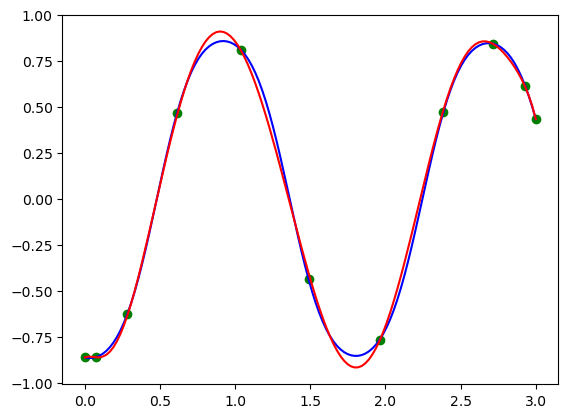

In [9]:
from numpy.polynomial.chebyshev import chebvander, chebval

i = np.random.randint(0, 1000)
plt.plot(times, trajs[i, 0], color='blue')

times_mapped = (2 * times - 3) / 3
plt.plot(times, chebval(times_mapped, coeffs_dct[i]), color='red')

#plt.plot(times, chebval(times, coeffs), color='green')

plt.scatter(times[closest_idx], trajs[i, 0, closest_idx], color='green')

In [10]:
from cd_poly import CDPolynomial

p = CDPolynomial(coeffs_dct, degree=3)

In [11]:
coeffs_dct.shape

(10000, 11)

In [12]:
print(f'Fraction of in-distribution samples classified as ood: {(p(coeffs_dct) > p.mean).mean()}')

Fraction of in-distribution samples classified as ood: 0.1858


In [13]:
p(coeffs_dct).min(), p(coeffs_dct).max()

(np.float64(13.888260851226466), np.float64(9994.15218732585))

In [14]:
param_dists_ood = param_dists.copy()
param_dists_ood['b'] = stats.uniform(1., 0.)
_, trajs_ood = gen_trajs(1000, 3., 128, param_dists_ood)
trajs_ood = to_sincos(trajs_ood)
trajs_ood.shape

(1000, 3, 128)

In [15]:
nodes = chebyshev_nodes(0., 3., deg)
closest_idx = closest2nodes(times, nodes)
coeffs_dct_ood = chebyshev_coefficients(trajs_ood[:, 0, closest_idx[::-1]])
coeffs_dct_ood.shape

(1000, 11)

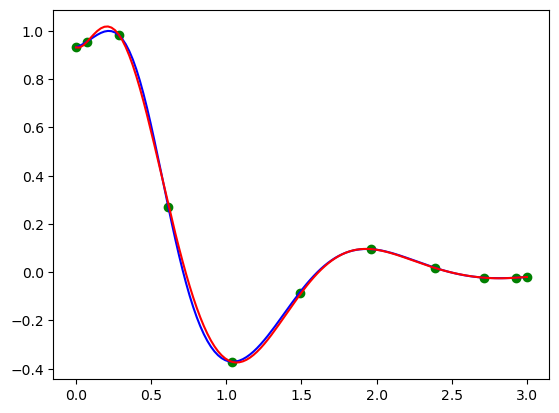

In [16]:
i = np.random.randint(0, 1000)
plt.plot(times, trajs_ood[i, 0], color='blue')

times_mapped = (2 * times - 3) / 3
plt.plot(times, chebval(times_mapped, coeffs_dct_ood[i]), color='red')

#plt.plot(times, chebval(times, coeffs), color='green')

plt.scatter(times[closest_idx], trajs_ood[i, 0, closest_idx], color='green')

In [17]:
p(coeffs_dct).max(), p(coeffs_dct_ood).min()

(np.float64(9994.15218732585), np.float64(791.4714987738463))

In [18]:
(p(coeffs_dct_ood) > p.mean).mean()

np.float64(1.0)

In [20]:
degree = 12
time = 3.
n_sim = 5

bs = np.linspace(0., .5, 20)
acc = np.zeros((len(bs), n_sim))

for b_idx, b in enumerate(bs):
    for i in range(n_sim):
        param_dists = {
        'q': stats.uniform(-np.pi, 2 * np.pi),
        'v': stats.norm(loc=0, scale=1),
        'b': stats.uniform(loc=0, scale=0.1)
        }
        times, trajs = gen_trajs(1_000, time, 128, param_dists)
        trajs = to_sincos(trajs)

        nodes = chebyshev_nodes(0., time, deg)
        closest_idx = closest2nodes(times, nodes)
        coeffs_dct = chebyshev_coefficients(trajs[:, 0, closest_idx[::-1]])
        
        p = CDPolynomial(coeffs_dct, degree=3)

        param_dists_ood = param_dists.copy()
        param_dists_ood['b'] = stats.uniform(b, 0.)
        _, trajs_ood = gen_trajs(1000, time, 128, param_dists_ood)
        trajs_ood = to_sincos(trajs_ood)

        coeffs_dct_ood = chebyshev_coefficients(trajs_ood[:, 0, closest_idx[::-1]])

        acc[b_idx, i] = (p(coeffs_dct_ood) > p.mean).mean()

KeyboardInterrupt: 

In [22]:
degree = 12
time = 3.
n_sim = 3

ls = np.linspace(.7, 1.3, 20)
acc = np.zeros((len(ls), n_sim))

for l_idx, l in enumerate(ls):
    for i in range(n_sim):
        param_dists = {
        'q': stats.uniform(-np.pi, 2 * np.pi),
        'v': stats.norm(loc=0, scale=1),
        'b': stats.uniform(loc=0, scale=0.1)
        }
        times, trajs = gen_trajs(1_000, time, 128, param_dists)
        trajs = to_sincos(trajs)

        nodes = chebyshev_nodes(0., time, deg)
        closest_idx = closest2nodes(times, nodes)
        coeffs_dct = chebyshev_coefficients(trajs[:, 0, closest_idx[::-1]])
        
        p = CDPolynomial(coeffs_dct, degree=3)

        _, trajs_ood = gen_trajs(1000, time, 128, param_dists, length=l)
        trajs_ood = to_sincos(trajs_ood)

        coeffs_dct_ood = chebyshev_coefficients(trajs_ood[:, 0, closest_idx[::-1]])

        acc[l_idx, i] = (p(coeffs_dct_ood) > p.mean).mean()
    print(f'Done with l = {l}.')

Done with l = 0.7.
Done with l = 0.731578947368421.
Done with l = 0.763157894736842.
Done with l = 0.7947368421052632.
Done with l = 0.8263157894736842.
Done with l = 0.8578947368421053.
Done with l = 0.8894736842105263.
Done with l = 0.9210526315789473.
Done with l = 0.9526315789473685.
Done with l = 0.9842105263157894.
Done with l = 1.0157894736842106.
Done with l = 1.0473684210526315.
Done with l = 1.0789473684210527.
Done with l = 1.1105263157894738.
Done with l = 1.1421052631578947.
Done with l = 1.1736842105263159.
Done with l = 1.2052631578947368.
Done with l = 1.236842105263158.
Done with l = 1.2684210526315791.
Done with l = 1.3.


In [23]:
acc

array([[1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   ],
       [0.999, 1.   , 1.   ],
       [0.997, 0.997, 0.995],
       [0.993, 0.99 , 0.989],
       [0.929, 0.942, 0.93 ],
       [0.936, 0.924, 0.93 ],
       [0.986, 0.981, 0.986],
       [1.   , 0.995, 1.   ],
       [0.997, 0.997, 1.   ],
       [1.   , 0.999, 0.998],
       [1.   , 0.999, 1.   ],
       [1.   , 1.   , 1.   ],
       [1.   , 1.   , 0.999],
       [1.   , 1.   , 1.   ],
       [1.   , 0.999, 1.   ]])

Text(0.5, 1.0, 'Accuracy on outlier detection')

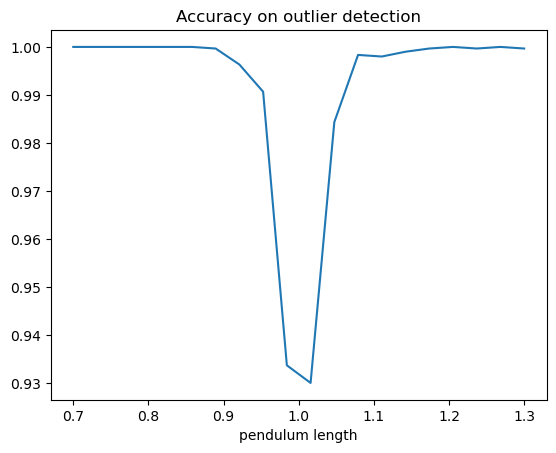

In [24]:
plt.plot(ls, acc.mean(axis=1))
plt.xlabel('pendulum length')
plt.title('Accuracy on outlier detection')

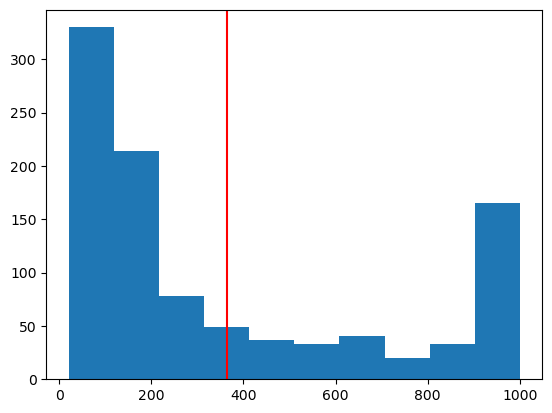

In [26]:
plt.hist(p(coeffs_dct))
plt.axvline(p(coeffs_dct).mean(), color='red')